# K-Means Clustering — From First Principles

K-Means is one of the most widely used unsupervised learning algorithms. Given a dataset and a number $K$, it **partitions the data into $K$ clusters** — groups where points are as close to one another as possible.

**No labels needed.** K-Means discovers structure directly from the data.

By the end of this notebook you will:
- Derive the **WCSS objective** K-Means minimizes
- Work through the **E-step** (assign) and **M-step** (update) from first principles
- Implement K-Means **from scratch** with NumPy, including K-Means++ initialization
- Visualize **centroid movement** across iterations
- Use the **elbow method** to select $K$
- Explore $K$ interactively with a slider

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs
import ipywidgets as widgets
from IPython.display import display

np.random.seed(42)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

COLORS = ["steelblue", "tomato", "mediumseagreen", "darkorange", "navy", "mediumpurple"]

## 1 · Intuition

Imagine a scatter of points — city locations, customer purchases, gene expression levels — with no labels. You want to group them by similarity.

A natural criterion: **points in the same group should be close to each other and far from other groups.** K-Means formalizes this by:

1. Placing a **centroid** $\boldsymbol{\mu}_k$ at the center of each group
2. Assigning each point to its nearest centroid (**E-step**)
3. Moving each centroid to the mean of its assigned points (**M-step**)
4. Repeating 2–3 until convergence

| Step | Name | What it does |
|------|------|--------------|
| **E** | Assignment | Send each point to its nearest centroid |
| **M** | Update | Move each centroid to the mean of its cluster |

These two steps alternate until the centroids stop moving.

> **Key insight:** "K-Means" literally names the update rule — each centroid becomes the **mean** of the **K** groups.

---

## 2 · Mathematical Formulation

### Notation

| Symbol | Meaning |
|--------|---------|
| $N$ | Number of data points |
| $K$ | Number of clusters |
| $d$ | Feature dimension |
| $\mathbf{x}_i \in \mathbb{R}^d$ | The $i$-th data point |
| $\boldsymbol{\mu}_k \in \mathbb{R}^d$ | Centroid of cluster $k$ |
| $r_{ik} \in \{0,1\}$ | 1 if point $i$ is in cluster $k$, 0 otherwise |

### Objective — Within-Cluster Sum of Squares (WCSS)

We want to minimize the total squared distance from each point to its cluster centroid:

$$\mathcal{L}(\{\boldsymbol{\mu}_k\},\, \{r_{ik}\}) = \sum_{i=1}^{N} \sum_{k=1}^{K} r_{ik}\, \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

subject to $\displaystyle\sum_{k=1}^K r_{ik} = 1$ for all $i$ (each point belongs to exactly one cluster).

This is a **combinatorial** problem (hard to solve globally). K-Means uses **coordinate descent** — alternately optimize over $r_{ik}$ and $\boldsymbol{\mu}_k$.

---

### E-Step: Optimize $r_{ik}$ with $\boldsymbol{\mu}_k$ fixed

For a fixed point $\mathbf{x}_i$, its contribution is $\displaystyle\sum_{k} r_{ik}\, \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$.

Since exactly one $r_{ik} = 1$, this is minimized by choosing the **nearest centroid**:

$$r_{ik} = \begin{cases} 1 & k = \displaystyle\arg\min_{k'}\, \|\mathbf{x}_i - \boldsymbol{\mu}_{k'}\|^2 \\ 0 & \text{otherwise} \end{cases}$$

---

### M-Step: Optimize $\boldsymbol{\mu}_k$ with $r_{ik}$ fixed

With assignments fixed, the objective decouples across clusters. For cluster $k$:

$$\mathcal{L}_k = \sum_{i=1}^{N} r_{ik}\, \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

Taking the gradient and setting to zero:

$$\frac{\partial \mathcal{L}_k}{\partial \boldsymbol{\mu}_k} = -2 \sum_{i=1}^{N} r_{ik}\,(\mathbf{x}_i - \boldsymbol{\mu}_k) = \mathbf{0}$$

$$\sum_{i} r_{ik}\,\mathbf{x}_i = \boldsymbol{\mu}_k \sum_{i} r_{ik}$$

$$\boxed{\boldsymbol{\mu}_k = \frac{\displaystyle\sum_{i=1}^{N} r_{ik}\,\mathbf{x}_i}{\displaystyle\sum_{i=1}^{N} r_{ik}}}$$

This is the **mean** of all points assigned to cluster $k$.

> **Key insight:** Both steps are guaranteed to decrease $\mathcal{L}$ (or leave it unchanged). Since $\mathcal{L} \geq 0$, the algorithm always converges — though possibly to a local minimum.

---

## 3 · Dataset

We generate 300 two-dimensional points from **4 Gaussian blobs**. This is ideal because:
- 2D lets us see clusters and centroids directly on a scatter plot
- Gaussian blobs mimic real-world cluster structure (customer segments, image regions)
- With $K = 4$ true blobs we can verify whether the algorithm recovers them

---

In [2]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=42)
N, d = X.shape
K_TRUE = 4

print(f"Dataset: {N} points in {d}D")
print(f"x1 range: [{X[:, 0].min():.2f}, {X[:, 0].max():.2f}]")
print(f"x2 range: [{X[:, 1].min():.2f}, {X[:, 1].max():.2f}]")

Dataset: 300 points in 2D
x1 range: [-11.06, 6.72]
x2 range: [-8.72, 11.23]


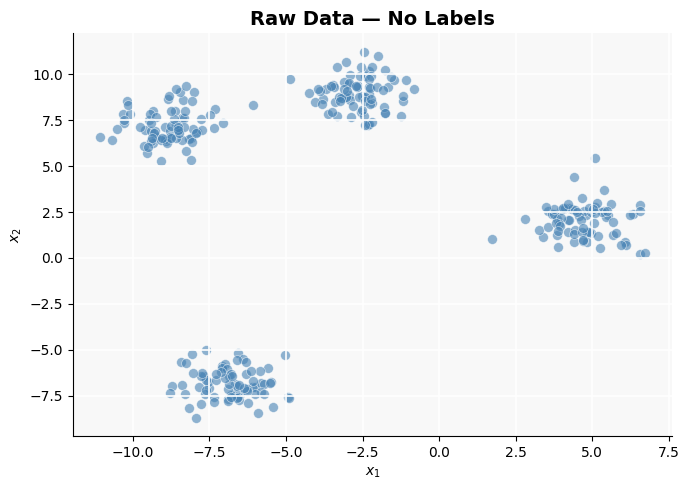

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[:, 0], X[:, 1], color="steelblue", alpha=0.6,
           edgecolors="white", linewidths=0.5, s=50)
ax.set_title("Raw Data — No Labels", fontsize=14, fontweight="bold")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.tight_layout()
plt.show()

## 4 · The Algorithm from Scratch

Our implementation includes:

- **K-Means++ initialization** — spread starting centroids to reduce bad local minima
- **Vectorized E-step** — compute all $N \times K$ distances at once with broadcasting
- **M-step** — per-cluster mean update (closed-form, no gradient descent needed)
- **History recording** — centroid positions, labels, and inertia at every iteration

### K-Means++ Initialization

Random starts can place all centroids in the same region. K-Means++ fixes this: pick centroids one at a time, with each new centroid chosen with probability proportional to its squared distance from the nearest already-chosen centroid:

$$p_i \propto \min_{k \text{ already chosen}} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

This naturally spreads starting centroids across the data and typically halves the number of iterations needed.

---

In [4]:
class KMeans:
    def __init__(self, k=4, max_iter=100, tol=1e-4, init="kmeans++", random_state=42):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.init = init
        self.random_state = random_state

    def _init_centroids(self, X):
        rng = np.random.default_rng(self.random_state)
        if self.init == "random":
            return X[rng.choice(len(X), self.k, replace=False)].copy()
        # K-Means++ initialization
        first = rng.integers(len(X))
        centroids = [X[first].copy()]
        for _ in range(self.k - 1):
            sq_dists = np.min(
                np.stack([np.sum((X - c) ** 2, axis=1) for c in centroids]),
                axis=0,
            )
            probs = sq_dists / sq_dists.sum()
            centroids.append(X[rng.choice(len(X), p=probs)].copy())
        return np.array(centroids)

    def _assign(self, X, centroids):
        # Broadcast: (N, 1, d) - (1, K, d) -> (N, K, d) -> sum -> (N, K)
        diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
        return np.argmin((diff ** 2).sum(axis=2), axis=1)

    def _update(self, X, labels):
        return np.array([X[labels == k].mean(axis=0) for k in range(self.k)])

    def _inertia(self, X, labels, centroids):
        return float(
            sum(np.sum((X[labels == k] - centroids[k]) ** 2) for k in range(self.k))
        )

    def fit(self, X):
        centroids = self._init_centroids(X)
        self.centroid_history_ = [centroids.copy()]
        self.label_history_    = []
        self.inertia_history_  = []

        for i in range(self.max_iter):
            labels = self._assign(X, centroids)
            self.label_history_.append(labels.copy())
            self.inertia_history_.append(self._inertia(X, labels, centroids))

            new_centroids = self._update(X, labels)
            shift = np.sqrt(np.sum((new_centroids - centroids) ** 2))
            centroids = new_centroids
            self.centroid_history_.append(centroids.copy())

            if shift < self.tol:
                print(f"Converged after {i + 1} iterations  (centroid shift = {shift:.2e})")
                break
        else:
            print(f"Reached max_iter = {self.max_iter}")

        self.centroids_  = centroids
        self.labels_     = labels
        self.n_iter_     = i + 1
        self.inertia_    = self.inertia_history_[-1]
        return self

In [5]:
km = KMeans(k=K_TRUE, max_iter=50, random_state=42)
km.fit(X)

print(f"\nFinal inertia : {km.inertia_:.2f}")
print(f"Iterations    : {km.n_iter_}")
print("\nLearned centroids:")
for k, mu in enumerate(km.centroids_):
    n_k = (km.labels_ == k).sum()
    print(f"  Cluster {k}:  mu = ({mu[0]:.3f}, {mu[1]:.3f})   n = {n_k}")

Converged after 3 iterations  (centroid shift = 0.00e+00)

Final inertia : 458.75
Iterations    : 3

Learned centroids:
  Cluster 0:  mu = (-8.833, 7.205)   n = 75
  Cluster 1:  mu = (4.710, 2.035)   n = 75
  Cluster 2:  mu = (-6.837, -6.835)   n = 75
  Cluster 3:  mu = (-2.653, 8.982)   n = 75


## 5 · Visualizing the Iterations

Each panel below shows the cluster assignments **after** that iteration's E-step, plus the centroids **before and after** the M-step. Arrows show the centroid shift. Watch how centroids migrate toward the true blob centers over successive iterations.

---

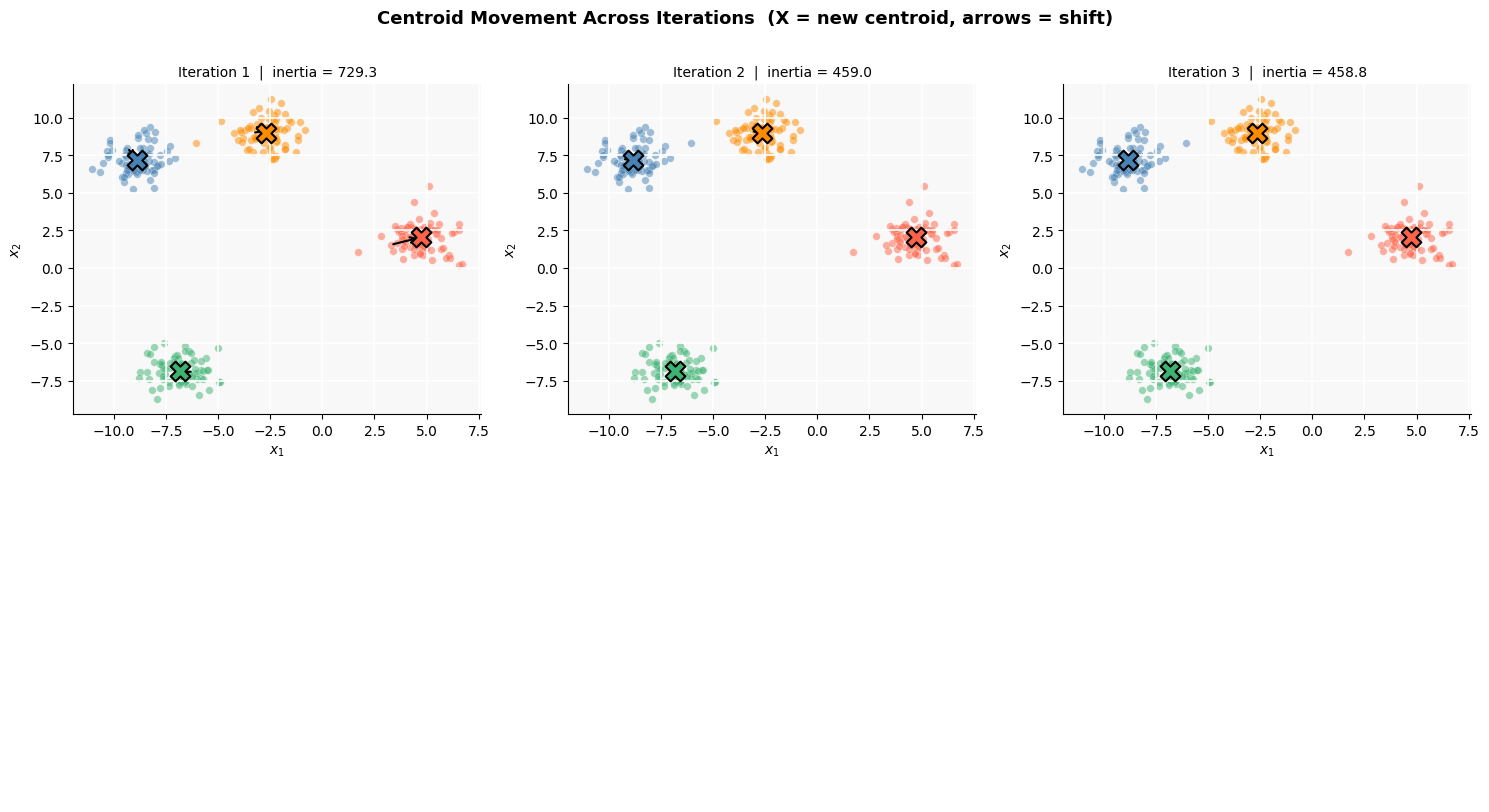

In [6]:
n_snap = min(6, km.n_iter_)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, ax in enumerate(axes):
    if idx >= n_snap:
        ax.axis("off")
        continue

    labels   = km.label_history_[idx]
    c_before = km.centroid_history_[idx]
    c_after  = km.centroid_history_[idx + 1]

    for k in range(km.k):
        mask = labels == k
        ax.scatter(X[mask, 0], X[mask, 1], color=COLORS[k],
                   alpha=0.5, s=30, edgecolors="white", linewidths=0.3)

    for k in range(km.k):
        ax.annotate(
            "", xy=c_after[k], xytext=c_before[k],
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
        )
        ax.scatter(*c_after[k], marker="X", s=200, color=COLORS[k],
                   edgecolors="black", linewidths=1.5, zorder=5)

    ax.set_title(f"Iteration {idx + 1}  |  inertia = {km.inertia_history_[idx]:.1f}",
                 fontsize=10)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

plt.suptitle("Centroid Movement Across Iterations  (X = new centroid, arrows = shift)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6 · Inertia Curve

The inertia $\mathcal{L}$ (WCSS) decreases **monotonically** — each E-step and M-step either reduces it or leaves it unchanged. The curve flattens rapidly as the algorithm settles near the solution.

---

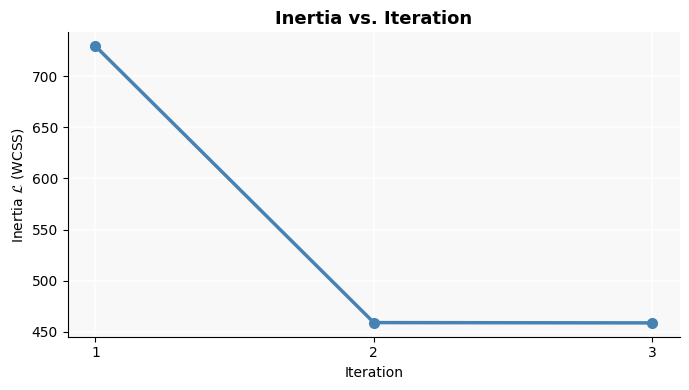

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, km.n_iter_ + 1), km.inertia_history_,
        marker="o", color="steelblue", linewidth=2.5, markersize=7)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"Inertia $\mathcal{L}$ (WCSS)")
ax.set_title("Inertia vs. Iteration", fontsize=13, fontweight="bold")
ax.set_xticks(range(1, km.n_iter_ + 1))
plt.tight_layout()
plt.show()

## 7 · Final Clustering Result

The left panel shows the converged clusters. The right panel shows **decision regions** — for any new point, the background color indicates which cluster it would be assigned to. This is computed by running the E-step on a fine 2D grid.

---

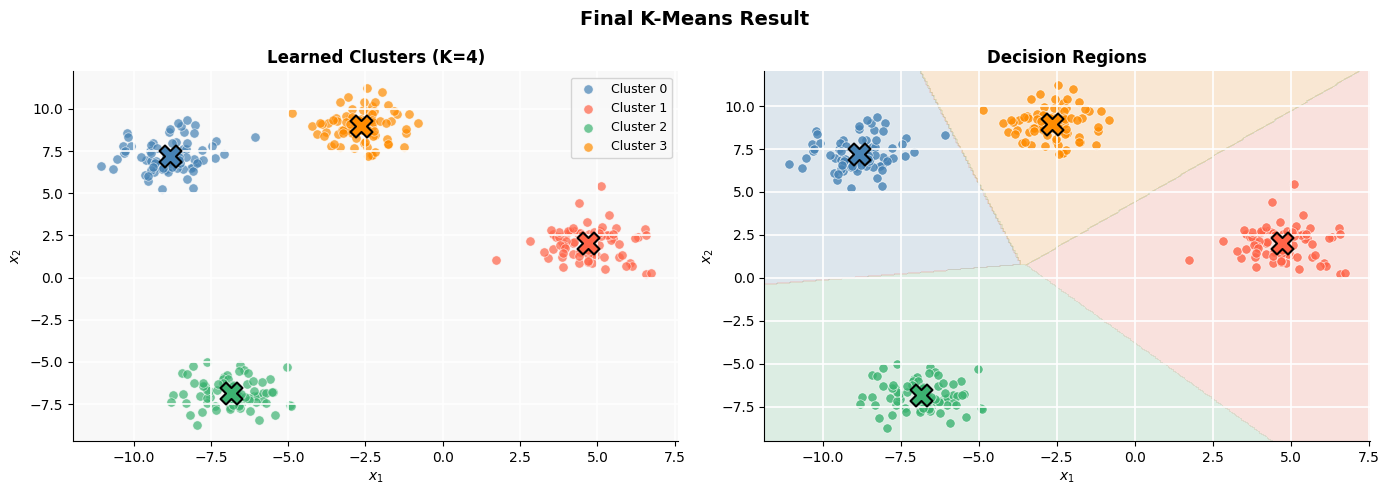

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter
ax = axes[0]
for k in range(km.k):
    mask = km.labels_ == k
    ax.scatter(X[mask, 0], X[mask, 1], color=COLORS[k], alpha=0.7,
               s=45, edgecolors="white", linewidths=0.5, label=f"Cluster {k}")
    ax.scatter(*km.centroids_[k], marker="X", s=250, color=COLORS[k],
               edgecolors="black", linewidths=1.5, zorder=5)
ax.set_title("Learned Clusters (K=4)", fontsize=12, fontweight="bold")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(loc="upper right", fontsize=9)

# Right: decision regions via meshgrid
ax = axes[1]
h = 0.06
x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_labels = km._assign(np.c_[xx.ravel(), yy.ravel()], km.centroids_).reshape(xx.shape)

cmap_bg = ListedColormap(COLORS[:km.k])
ax.contourf(xx, yy, grid_labels, alpha=0.15, cmap=cmap_bg,
            levels=np.arange(-0.5, km.k + 0.5))
for k in range(km.k):
    mask = km.labels_ == k
    ax.scatter(X[mask, 0], X[mask, 1], color=COLORS[k], alpha=0.8,
               s=45, edgecolors="white", linewidths=0.5)
    ax.scatter(*km.centroids_[k], marker="X", s=250, color=COLORS[k],
               edgecolors="black", linewidths=1.5, zorder=5)
ax.set_title("Decision Regions", fontsize=12, fontweight="bold")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

plt.suptitle("Final K-Means Result", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8 · Choosing K — The Elbow Method

K-Means requires specifying $K$ in advance — but how do we pick it?

Adding more clusters always reduces inertia (more groups = shorter distances), so we can't simply minimize $\mathcal{L}$ over $K$. Instead we look for the **elbow**: the value of $K$ after which extra clusters give diminishing returns.

$$\text{If adding one more cluster barely reduces } \mathcal{L}, \text{ you already have enough clusters.}$$

**Procedure:** fit K-Means for $K = 1, 2, \ldots, K_{\max}$, plot inertia vs. $K$, and look for the bend.

---

Converged after 2 iterations  (centroid shift = 0.00e+00)
  K= 1  inertia = 19861.3
Converged after 3 iterations  (centroid shift = 0.00e+00)
  K= 2  inertia = 9960.2
Converged after 3 iterations  (centroid shift = 0.00e+00)
  K= 3  inertia = 2009.2
Converged after 3 iterations  (centroid shift = 0.00e+00)
  K= 4  inertia = 458.8
Converged after 11 iterations  (centroid shift = 0.00e+00)
  K= 5  inertia = 417.5
Converged after 11 iterations  (centroid shift = 0.00e+00)
  K= 6  inertia = 377.4
Converged after 11 iterations  (centroid shift = 0.00e+00)
  K= 7  inertia = 334.2
Converged after 11 iterations  (centroid shift = 0.00e+00)
  K= 8  inertia = 298.6
Converged after 11 iterations  (centroid shift = 0.00e+00)
  K= 9  inertia = 269.5


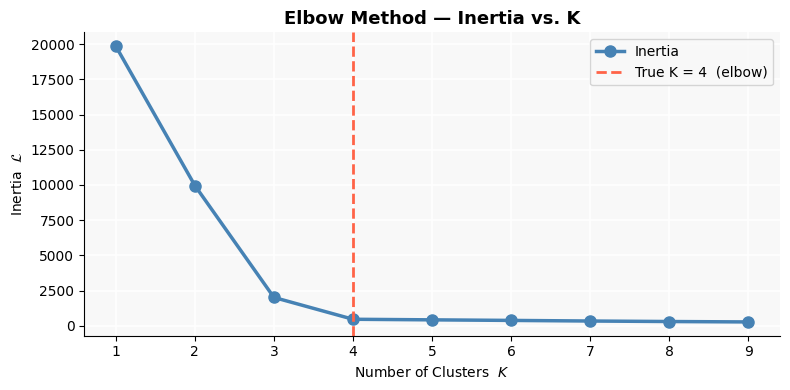

In [9]:
K_range = range(1, 10)
elbow_inertias = []

for k in K_range:
    km_k = KMeans(k=k, max_iter=100, random_state=42)
    km_k.fit(X)
    elbow_inertias.append(km_k.inertia_)
    print(f"  K={k:2d}  inertia = {km_k.inertia_:.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), elbow_inertias, marker="o", color="steelblue",
        linewidth=2.5, markersize=8, label="Inertia")
ax.axvline(x=4, color="tomato", linestyle="--", linewidth=2, label="True K = 4  (elbow)")
ax.set_xlabel("Number of Clusters  $K$")
ax.set_ylabel(r"Inertia  $\mathcal{L}$")
ax.set_title("Elbow Method — Inertia vs. K", fontsize=13, fontweight="bold")
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.show()

## 9 · Interactive Explorer — Effect of K

Use the slider to change $K$ and observe how cluster assignments shift.

- **K < 4**: True blobs are merged — structure is lost
- **K = 4**: Recovers the true blob structure
- **K > 4**: Blobs are split — finer granularity but may be overfitting the structure

---

In [10]:
def plot_kmeans_interactive(k):
    km_w = KMeans(k=k, max_iter=100, random_state=42)
    km_w.fit(X)

    fig, ax = plt.subplots(figsize=(7, 5))
    for i in range(k):
        mask = km_w.labels_ == i
        ax.scatter(X[mask, 0], X[mask, 1], color=COLORS[i % len(COLORS)],
                   alpha=0.7, s=45, edgecolors="white", linewidths=0.5)
        ax.scatter(*km_w.centroids_[i], marker="X", s=260,
                   color=COLORS[i % len(COLORS)], edgecolors="black",
                   linewidths=1.5, zorder=5)

    ax.set_title(f"K-Means  (K = {k})   |   inertia = {km_w.inertia_:.1f}",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(
    value=4, min=1, max=8, step=1,
    description="K:",
    style={"description_width": "initial"},
)
widgets.interact(plot_kmeans_interactive, k=slider);

interactive(children=(IntSlider(value=4, description='K:', max=8, min=1, style=SliderStyle(description_width='…

---

## Summary

| Concept | Key Idea |
|---------|----------|
| **Objective (WCSS)** | Minimize $\sum_{i,k} r_{ik} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$ — total squared distance to cluster centroids |
| **E-Step** | Assign each point to its nearest centroid — a simple argmin over $K$ distances |
| **M-Step** | Move each centroid to the mean of its assigned points — closed-form, no gradient descent |
| **Convergence** | Both steps are non-increasing in $\mathcal{L}$; algorithm always terminates (may be local minimum) |
| **K-Means++** | Initialize centroids with probability $\propto$ distance² — faster convergence, fewer bad starts |
| **Inertia** | The WCSS value; monotonically decreasing across iterations, bounded below by 0 |
| **Elbow Method** | Plot inertia vs. $K$; choose $K$ at the point of diminishing returns |
| **Complexity** | $\mathcal{O}(N \cdot K \cdot d \cdot T)$ per run — scales linearly with data size |
| **Limitation** | Assumes convex, roughly equal-sized clusters; sensitive to outliers and poor initialization |